In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [5]:
data = pd.read_csv("diabetes.csv")

In [6]:
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[cols] = data[cols].replace(0, np.nan)

In [9]:
data.fillna(data.mean(), inplace=True)

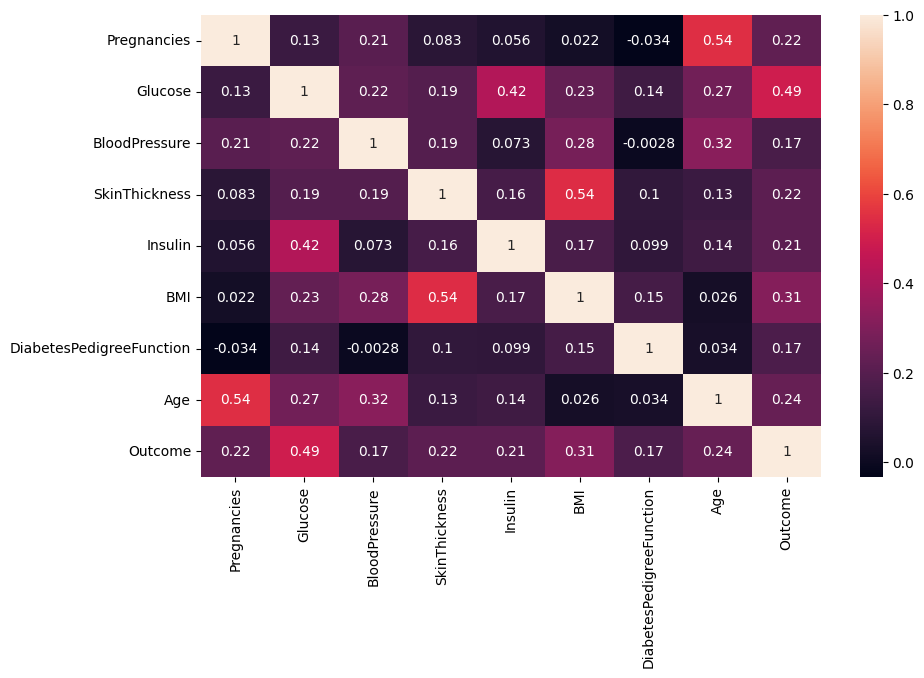

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.show()

In [11]:
X = data.drop("Outcome", axis=1)

In [12]:
y = data["Outcome"]

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [18]:
y_pred = lr_model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)

In [20]:
precision = precision_score(y_test, y_pred)

In [21]:
recall = recall_score(y_test, y_pred)

In [24]:
f1 = f1_score(y_test, y_pred)

In [22]:
roc = roc_auc_score(y_test, y_pred)

In [25]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc)

Accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1 Score: 0.6415094339622641
ROC-AUC: 0.7232323232323232


In [37]:
lr_pred = lr_model.predict(X_test)
svm_pred = svm_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

In [28]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [lr_accuracy, svm_accuracy, rf_accuracy],
    "F1 Score": [lr_f1, svm_f1, rf_f1]
})

print(comparison)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.753247  0.641509
1                  SVM  0.753247  0.627451
2        Random Forest  0.759740  0.672566


In [34]:
input_data = pd.DataFrame(
[[6,148,72,35,0,33.6,0.627,50]],
columns=[
'Pregnancies','Glucose','BloodPressure',
'SkinThickness','Insulin','BMI',
'DiabetesPedigreeFunction','Age'
])
input_scaled = scaler.transform(input_data)
prediction = lr_model.predict(input_scaled)

if prediction[0] == 1:
    print("The model predicts that the patient is likely to have diabetes.")
else:
    print("The model predicts that the patient is unlikely to have diabetes.")

The model predicts that the patient is likely to have diabetes.


In [31]:
import joblib

joblib.dump(lr_model, "disease_prediction_model.pkl")

['disease_prediction_model.pkl']

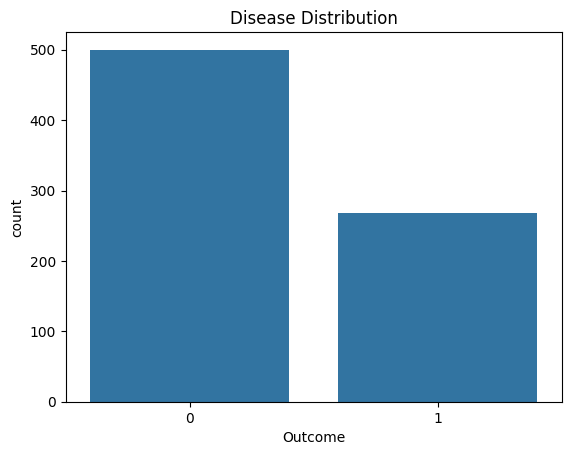

In [32]:
sns.countplot(x='Outcome', data=data)
plt.title("Disease Distribution")
plt.show()

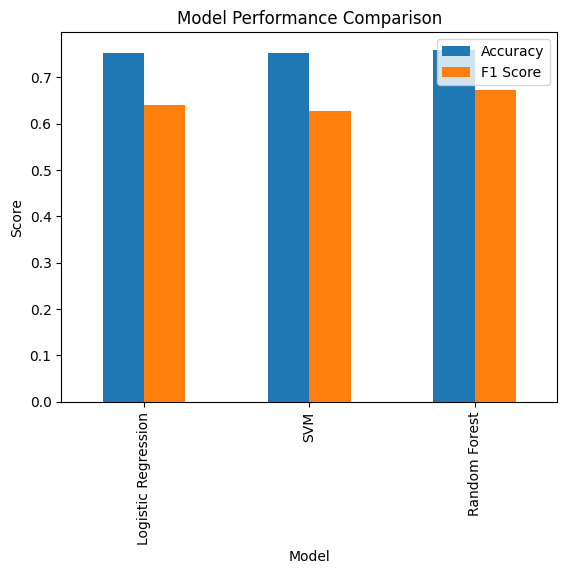

In [33]:
comparison.set_index("Model")[["Accuracy","F1 Score"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

In [35]:
import os
os.listdir()

['.config', 'disease_prediction_model.pkl', 'diabetes.csv', 'sample_data']

In [36]:
from google.colab import files
files.download("disease_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>